In [72]:
import json
import os
from pathlib import Path

import ee
import ee.deserializer
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
ee.Initialize(project="ee-ursa-test")

In [3]:
data_path = Path(os.environ["DATA_PATH"])
heat_islands_path = Path(os.environ["HEAT_ISLANDS_PATH"])

In [36]:
df = (
    gpd.read_file(data_path / "USOS_DE_SUELO_EXITS_24")
    .filter(["USOSUELO24", "geometry"])
    .assign(geometry=lambda df: df["geometry"].force_2d())
    .assign(geometry=lambda df: df["geometry"].centroid)
    .to_crs("EPSG:4326")
)

In [5]:
with open(
    heat_islands_path
    / "generated"
    / "raster_zone"
    / "temp_seasonal"
    / "02.2.03"
    / "2024_summer.json",
) as f:
    img: ee.image.Image = ee.deserializer.decode(json.load(f))

In [37]:
chunk_size = 4500
df_chunked = np.array_split(df, len(df) // chunk_size + 1)

c:\Users\lain\Documents\mexicali-zone\.venv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\lain\Documents\mexicali-zone\.venv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\lain\Documents\mexicali-zone\.venv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\lain\Documents\mexicali-zone\.venv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transp

In [64]:
res = []
for chunk in df_chunked:
    test = geemap.geopandas_to_ee(chunk)
    out = img.reduceRegions(test, ee.reducer.Reducer.mean(), scale=30).getInfo()
    res.extend([x["properties"] for x in out["features"]])

In [65]:
df_test = pd.DataFrame(res)

In [66]:
df_test["USOSUELO24"].value_counts()

USOSUELO24
Habitacional                  15069
Comercio y servicios           3970
Baldíos                        3366
Equipamiento                   1152
Rústicos                        616
Agrícola                        560
Área verde                      534
Mixto                           422
Industrial                      296
Infraestructura                 127
Almacenamiento y servicios       49
Conservación                     14
Name: count, dtype: int64

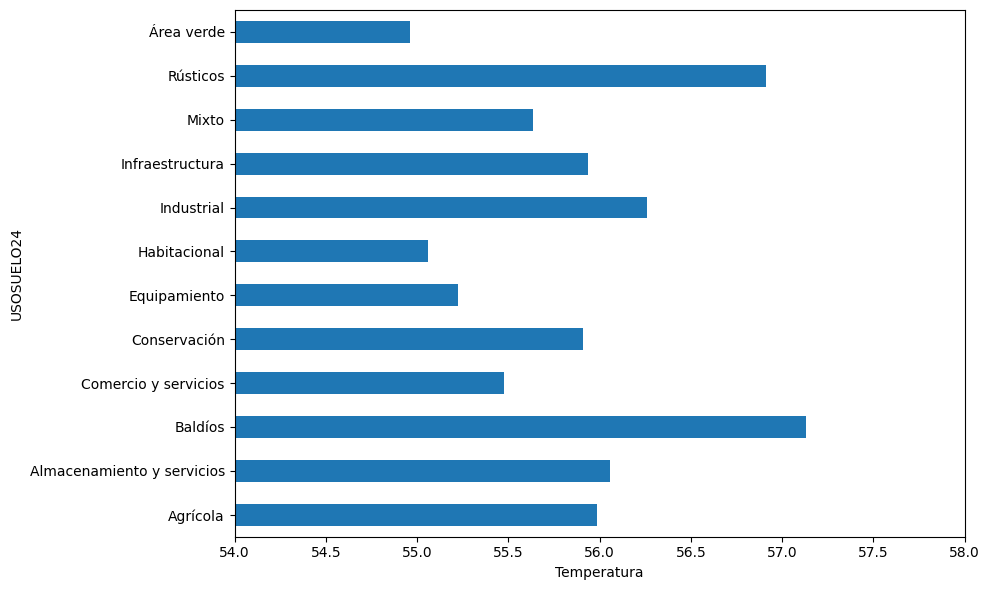

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))
df_test.groupby("USOSUELO24")["ST_B10"].median().plot.barh(ax=ax)
ax.set_xlabel("Temperatura")
ax.set_xlim(54, 58)
fig.tight_layout()

In [ ]:
m = geemap.Map()
m.addLayer(img)
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…